In [1]:
# Imposta questa variabile a False se non vuoi salvare i grafici in locale
salva_grafici = True


# Analisi NLP su Report di Food Insecurity

### 1. Setup, Importazioni e Caricamento Dati


In [1]:
import os
import re
import pandas as pd
import numpy as np
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import ipywidgets as widgets
from IPython.display import display, clear_output

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap

# Verifica e carica il modello spaCy
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import os
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load('en_core_web_sm')



In [2]:
def extract_years_from_period(period_string):
    if pd.isna(period_string):
        return []
    years = re.findall(r'\d{4}', str(period_string))
    return [int(year) for year in years]

print('Caricamento dataset anonimizzato...')
csv_path = r'C:\Users\skywa\Documents\PROGETTONE\GDELT\nlp_embedding\report_anonimizzati.csv'

if os.path.exists(csv_path):
    df_raw = pd.read_csv(csv_path)
    
    # Rinomina colonne per compatibilità con il resto del notebook
    df_documents = df_raw.rename(columns={
        'nome_file': 'filename',
        'paese': 'country',
        'periodo': 'period',
        'report_anonimo': 'text'
    })[['filename', 'country', 'period', 'text']]
    
    # Rimuovi i tag di anonimizzazione (es. [AFFECTED_AREA], [DATE], [REDACTED])
    print('Rimozione dei tag di anonimizzazione...')
    df_documents['text'] = df_documents['text'].apply(lambda x: re.sub(r'\[.*?\]', '', str(x)) if pd.notnull(x) else x)
    
    # Estrai anni dal periodo
    df_documents['years_in_period'] = df_documents['period'].apply(extract_years_from_period)

    print(f'Total documents loaded into DataFrame: {len(df_documents)}')
    display(df_documents.head())
else:
    print(f'ERRORE: File {csv_path} non trovato!')


Caricamento dataset anonimizzato...
Rimozione dei tag di anonimizzazione...
Total documents loaded into DataFrame: 497


,filename,country,period,text,years_in_period
0,Democratic_Republic_of_the_Congo_Dec_2012_-_De...,Democratic Republic of the Congo,Dec 2012 / Dec 2012,The 8th analysis cycle on the Integrated Food ...,"[2012, 2012]"
1,Burundi_Nov_2024_-_Mar_2025_KeyResults.txt,Burundi,Nov 2024 / Mar 2025,"Between January and March , which coincides wi...","[2024, 2025]"
2,Madagascar_Aug_2017_-_Mar_2018_KeyResults.txt,Madagascar,Aug 2017 / Mar 2018,The period from August to October coincides w...,"[2017, 2018]"
3,Yemen_Oct_2023_-_Feb_2024_KeyResults.txt,Yemen,Oct 2023 / Feb 2024,The updated analysis indicates that for the pe...,"[2023, 2024]"
4,Mozambique_Apr_2018_-_Sep_2018_KeyResults.txt,Mozambique,Apr 2018 / Sep 2018,DISCLAIMER: please note that this IPC Acute Fo...,"[2018, 2018]"


### 2. Definizione Stopwords (Custom + Entità Geografiche)


In [3]:
# 1. Stopword Manuali/Dominio
custom_stopwords = {'ipc', 'phase', 'million', 'country', 'level', 'percent', 'classify', 'area', 'analysis', 'period', 'season', 'state',
                    'analysed', 'projection', 'region', 'district', 'current', 'number', 'total', 'likely', 'province','factor', 'main', 'result', 'zone'}

# 2. Aggiunta dei lemmi delle custom stopwords
lemmatized_custom_stopwords = set()
for word in custom_stopwords:
    doc = nlp(word)
    for token in doc:
        lemmatized_custom_stopwords.add(token.lemma_.lower())

# Combinazione Finale Stopwords
final_stopwords = custom_stopwords.union(lemmatized_custom_stopwords)

print(f"Numero totale di custom stopword (manuali + lemmi): {len(final_stopwords)}\n")


Numero totale di custom stopword (manuali + lemmi): 26



### 3. Preprocessing del Testo (Estrazione Unigrammi e Bigrammi)


In [4]:
top_unigrams_per_doc = []
full_unigram_counts_per_doc = []
preprocessed_texts = []
top_bigrams_per_doc = []

all_unigrams_filtered = []
all_bigrams_filtered = []

if not df_documents.empty:
    for index, row in df_documents.iterrows():
        doc_text = row['text']
        doc = nlp(doc_text)

        # Filtro POS (Solo Nomi e Aggettivi) e Stopword
        filtered_lemmas = [
            token.lemma_.lower()
            for token in doc
            if not token.is_stop and not token.is_punct and token.is_alpha
            and token.lemma_.lower() not in final_stopwords
            and token.pos_ in ['NOUN', 'ADJ']
        ]

        all_unigrams_filtered.extend(filtered_lemmas)

        unigram_counts = Counter(filtered_lemmas)
        top_unigrams_per_doc.append(unigram_counts.most_common(10))
        full_unigram_counts_per_doc.append(dict(unigram_counts))
        preprocessed_texts.append(' '.join(filtered_lemmas))

        # Generazione Bigrammi
        bigrams_for_doc = [
            f"{filtered_lemmas[i]} {filtered_lemmas[i+1]}"
            for i in range(len(filtered_lemmas) - 1)
        ]
        all_bigrams_filtered.extend(bigrams_for_doc)

        bigram_counts = Counter(bigrams_for_doc)
        top_bigrams_per_doc.append(bigram_counts.most_common(10))

    df_documents['top_unigrams_per_doc'] = top_unigrams_per_doc
    df_documents['unigram_counts'] = full_unigram_counts_per_doc
    df_documents['preprocessed_text'] = preprocessed_texts
    df_documents['top_bigrams_per_doc'] = top_bigrams_per_doc

print("Estrazione completata. Calcolo Frequenze Globali...")

unigram_counts_filtered = Counter(all_unigrams_filtered)
bigram_counts_filtered = Counter(all_bigrams_filtered)

print("\n--- 20 parole (unigrammi) più comuni ---")
for word, count in unigram_counts_filtered.most_common(20):
    print(f"{word}: {count}")

print("\n--- 20 bigrammi più comuni ---")
for bigram, count in bigram_counts_filtered.most_common(20):
    print(f"{bigram}: {count}")


Estrazione completata. Calcolo Frequenze Globali...

--- 20 parole (unigrammi) più comuni ---
food: 3145
people: 1817
population: 1504
insecurity: 1173
high: 931
acute: 828
situation: 726
household: 721
price: 524
livelihood: 450
security: 440
access: 399
emergency: 382
poor: 376
production: 346
humanitarian: 343
harvest: 316
crop: 315
assistance: 313
crisis: 304

--- 20 bigrammi più comuni ---
food insecurity: 1068
acute food: 658
people population: 443
food security: 391
high acute: 359
population people: 239
food price: 221
food consumption: 195
population high: 188
security situation: 184
insecurity people: 181
people high: 169
people people: 162
acute malnutrition: 154
humanitarian assistance: 140
high food: 140
food insecure: 122
people emergency: 121
access food: 119
household food: 104


### 4. Analisi Esplorativa e Visualizzazioni


C:\Users\skywa\AppData\Local\Temp\ipykernel_26496\1642876280.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_top_unigrams, palette='viridis')


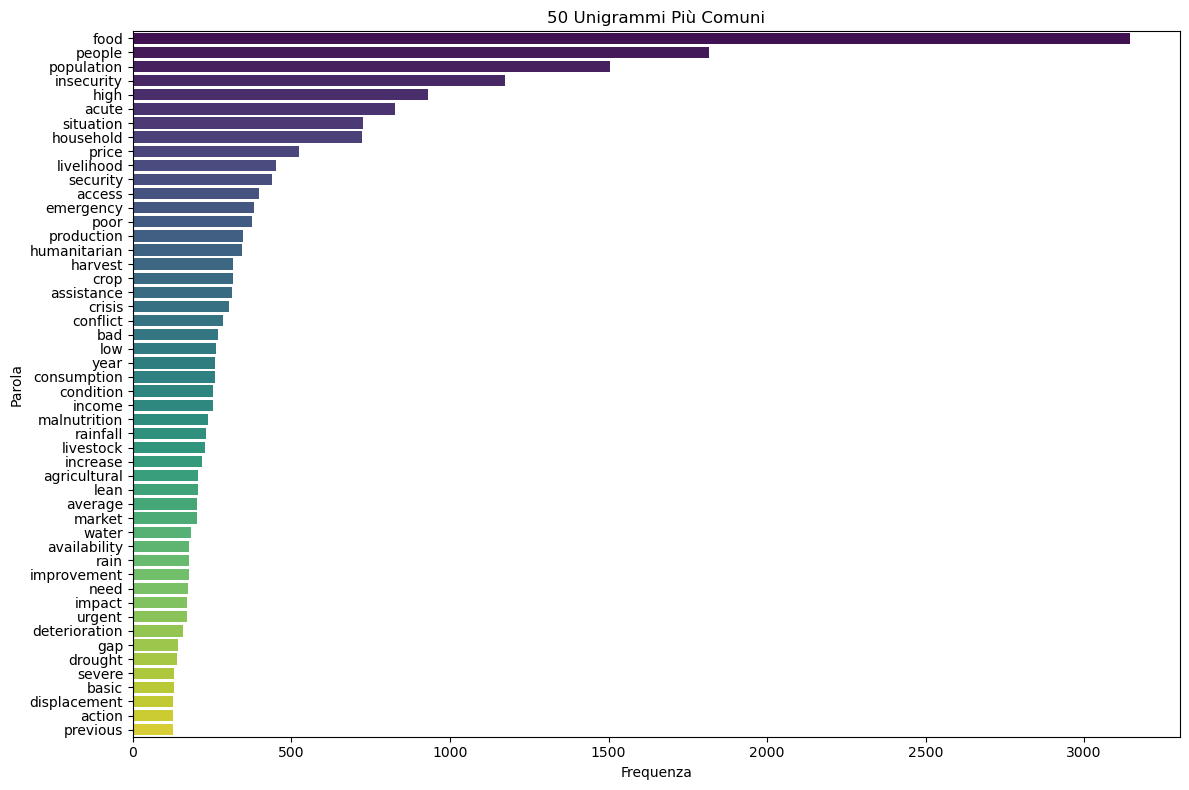

In [5]:
# Grafico a Barre degli Unigrammi Più Comuni
if unigram_counts_filtered:
    top_50_unigrams = unigram_counts_filtered.most_common(50)
    df_top_unigrams = pd.DataFrame(top_50_unigrams, columns=['Word', 'Frequency'])

    fig = plt.figure(figsize=(12, 8))
    sns.barplot(x='Frequency', y='Word', data=df_top_unigrams, palette='viridis')
    plt.title('50 Unigrammi Più Comuni')
    plt.xlabel('Frequenza')
    plt.ylabel('Parola')
    plt.tight_layout()
    plt.show()


--- Word Cloud Globale Statica (Top 100 parole) ---


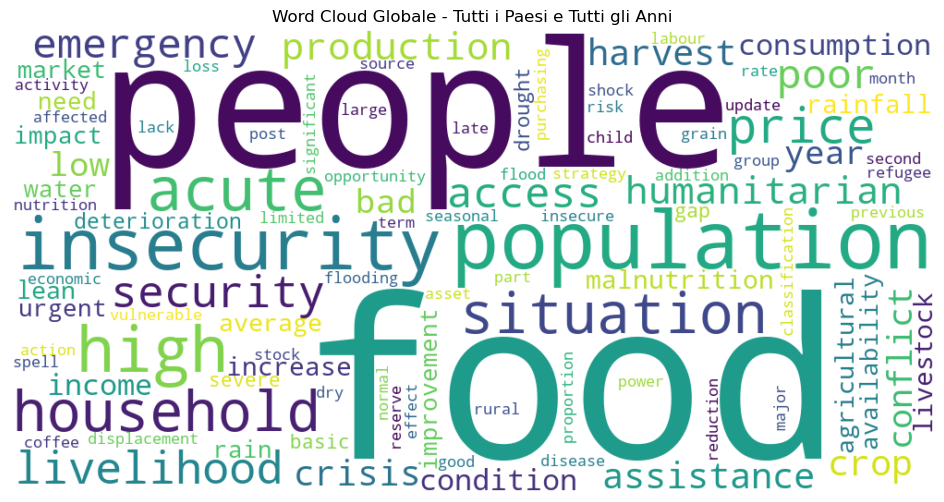

In [6]:
# Word Cloud Globale Statica (Top 100 parole)
print("--- Word Cloud Globale Statica (Top 100 parole) ---")
if 'unigram_counts_filtered' in globals() and unigram_counts_filtered:
    wordcloud_global = WordCloud(width=1000, height=500, background_color='white', random_state=42).generate_from_frequencies(dict(unigram_counts_filtered.most_common(100)))
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud_global, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud Globale - Tutti i Paesi e Tutti gli Anni')
    if globals().get('salva_grafici', True):
        plt.savefig('wordcloud_globale.png', bbox_inches='tight')
    plt.show()


In [7]:
# Word Cloud Interattiva
def generate_wordcloud_for_country_and_year(country_name, selected_year):
    filtered_docs = df_documents
    if country_name != 'Tutti i Paesi':
        filtered_docs = filtered_docs[filtered_docs['country'] == country_name]
    if selected_year != 0:
        filtered_docs = filtered_docs[filtered_docs['years_in_period'].apply(lambda y_list: selected_year in y_list)]

    if filtered_docs.empty:
        print(f"Nessun documento trovato per '{country_name}' e anno '{selected_year}'.")
        return

    cloud_counts = Counter()
    for counts_dict in filtered_docs['unigram_counts']:
        cloud_counts.update(counts_dict)
    if not cloud_counts:
        print("Nessuna parola trovata.")
        return

    wordcloud = WordCloud(width=800, height=400, background_color='white', random_state=42).generate_from_frequencies(dict(cloud_counts.most_common(50)))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {country_name} ({selected_year if selected_year != 0 else "Tutti gli Anni"})')
    if globals().get('salva_grafici', True):
        plt.savefig(f'wordcloud_{country_name.replace(" ", "_")}_{selected_year}.png', bbox_inches='tight')
    plt.show()

countries_options = ['Tutti i Paesi']
if not df_documents.empty:
    countries_options += sorted(df_documents['country'].unique().tolist())

country_selector_new = widgets.Dropdown(options=countries_options, value='Tutti i Paesi', description='Paese:')
year_selector = widgets.SelectionSlider(options=[0], value=0, description='Anno:', continuous_update=False)

def _update_year_slider(selected_country):
    if df_documents.empty:
        return

    if selected_country == 'Tutti i Paesi':
        available_years = sorted(list(set(y for years in df_documents['years_in_period'] for y in years)))
    else:
        available_years = sorted(list(set(y for years in df_documents[df_documents['country'] == selected_country]['years_in_period'] for y in years)))

    if available_years:
        year_selector.options = [0] + available_years
        year_selector.disabled = False
    else:
        year_selector.options = [0]
        year_selector.value = 0
        year_selector.disabled = True

def _on_country_change(change):
    _update_year_slider(change.new)

country_selector_new.observe(_on_country_change, names='value')
_update_year_slider(country_selector_new.value)

out = widgets.interactive_output(generate_wordcloud_for_country_and_year, {'country_name': country_selector_new, 'selected_year': year_selector})
display(widgets.VBox([widgets.Label("Word Cloud Interattiva (0 = Tutti gli Anni)"), country_selector_new, year_selector, out]))


In [9]:
# Se necessario, decommenta la riga sotto per installare le librerie necessarie
# !pip install holoviews bokeh pandas

import itertools
from collections import Counter
import holoviews as hv
from holoviews import opts, dim
hv.extension('bokeh')

if 'df_documents' in globals() and 'top_unigrams_per_doc' in df_documents.columns:
    print("Estrazione co-occorrenze in corso...")
    
    global_unigrams = Counter()
    for counts in df_documents['unigram_counts']:
        global_unigrams.update(counts)
    top_50_unigrams = set([w for w, c in global_unigrams.most_common(50)])
    
    generic_words = {'people', 'population', 'high', 'low', 'level', 'number', 'total', 'increase', 'decrease', 'analysis', 'phase', 'percent', 'country', 'area', 'report'}
    def is_valid_bigram(b_str):
        words = b_str.split()
        if len(words) != 2: return False
        if words[0] == words[1]: return False
        if any(w in generic_words for w in words): return False
        return True

    co_occurrences = Counter()
    
    for index, row in df_documents.iterrows():
        doc_unigrams = [word for word, count in row.get('top_unigrams_per_doc', []) if word in top_50_unigrams]
        doc_bigrams = [bigram.replace(' ', '_') for bigram, count in row.get('top_bigrams_per_doc', []) if is_valid_bigram(bigram)]
        doc_concepts = set(doc_unigrams + doc_bigrams)
        
        pairs = [frozenset([w1, w2]) for w1, w2 in itertools.combinations(doc_concepts, 2)]
        for pair in pairs:
            co_occurrences[pair] += 1

    # Creiamo il dataframe per HoloViews (Sorgente, Destinazione, Valore)
    links_data = []
    # Prendiamo le top 150 connessioni per evitare caos nel centro del cerchio
    for pair, weight in co_occurrences.most_common(150):
        w1, w2 = list(pair)
        links_data.append({'source': w1, 'target': w2, 'value': weight})
        
    df_links = pd.DataFrame(links_data)
    
    # Creazione Chord Diagram
    chord = hv.Chord(df_links)
    chord.opts(
        opts.Chord(
            cmap='Category20', edge_cmap='Category20', edge_color=dim('source').str(),
            labels='index', node_color=dim('index').str(),
            width=800, height=800, title="Top Co-occorrenze (Chord Diagram)"
        )
    )
    display(chord)
else:
    print("Esegui prima la fase di preprocessing!")


ModuleNotFoundError: No module named 'holoviews'

### 4.1. Heatmap dei Driver di Crisi per Paese
Mappiamo la frequenza dei termini relativi ai macro-driver (Conflitto, Clima, Economia, Agricoltura) nei report di ciascun paese, evidenziando i 'punti caldi'. I dati sono normalizzati in percentuale per riga.

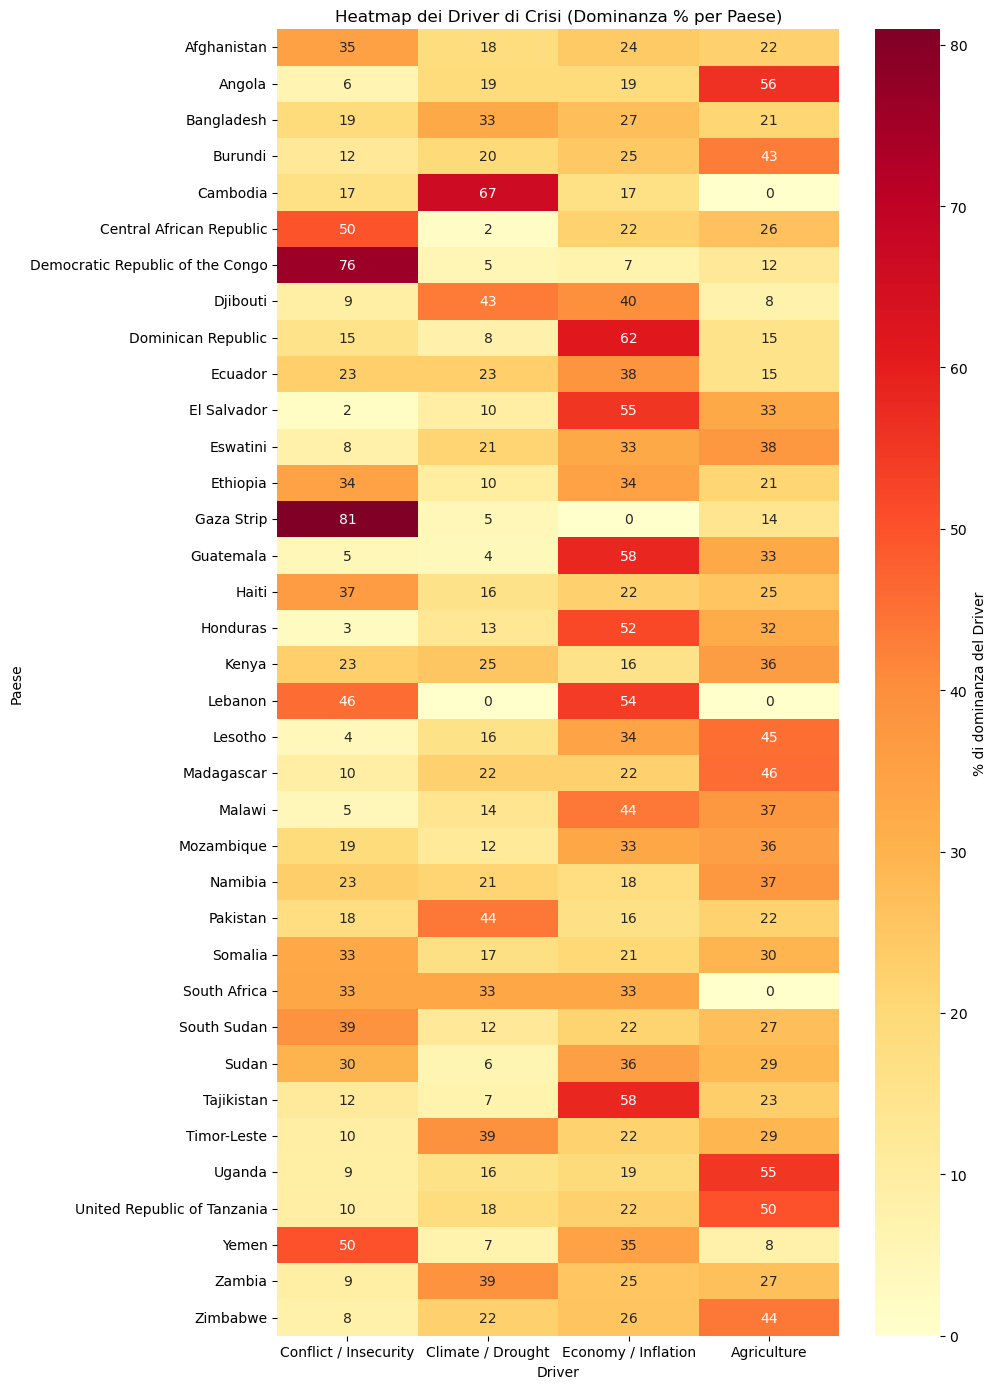

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'df_documents' in globals() and 'unigram_counts' in df_documents.columns:
    # Dizionario dei Driver e delle relative parole chiave
    drivers_dict = {
        'Conflict / Insecurity': ['conflict', 'violence', 'war', 'attack', 'displacement', 'security', 'clash', 'armed'],
        'Climate / Drought': ['drought', 'rain', 'dry', 'weather', 'flood', 'climate', 'shock', 'season'],
        'Economy / Inflation': ['inflation', 'price', 'market', 'economy', 'currency', 'income', 'cost', 'trade'],
        'Agriculture': ['crop', 'harvest', 'production', 'livestock', 'agriculture', 'yield', 'seed', 'pest']
    }
    
    driver_data = []
    
    for index, row in df_documents.iterrows():
        country = row['country']
        counts = row['unigram_counts']
        
        # Calcola le occorrenze totali per ogni driver in questo documento
        doc_drivers = {'Country': country}
        for driver_name, keywords in drivers_dict.items():
            total_occurrences = sum(counts.get(word, 0) for word in keywords)
            doc_drivers[driver_name] = total_occurrences
            
        driver_data.append(doc_drivers)
        
    df_drivers = pd.DataFrame(driver_data)
    
    # Aggreghiamo le occorrenze per paese (somma di tutti i documenti di quel paese)
    df_drivers_grouped = df_drivers.groupby('Country').sum()
    
    # Normalizziamo le righe (% del driver sul totale delle menzioni di driver per quel paese)
    row_sums = df_drivers_grouped.sum(axis=1) + 1e-9
    df_heatmap = df_drivers_grouped.div(row_sums, axis=0) * 100
    
    plt.figure(figsize=(10, 14))
    sns.heatmap(df_heatmap, cmap='YlOrRd', annot=True, fmt=".0f", cbar_kws={'label': '% di dominanza del Driver'})
    plt.title('Heatmap dei Driver di Crisi (Dominanza % per Paese)')
    plt.ylabel('Paese')
    plt.xlabel('Driver')
    plt.tight_layout()
    if globals().get('salva_grafici', True):
        plt.savefig('heatmap_driver.png', bbox_inches='tight')
    plt.show()
else:
    print("Esegui prima la fase di preprocessing per avere unigram_counts!")


### 5. Estrazione Feature: TF-IDF e LSA (TruncatedSVD) + UMAP


In [9]:
# Utilizziamo direttamente il testo già pre-processato salvato nel dataframe
# Questo evita di dover far girare di nuovo il pesantissimo modello spaCy!

if 'preprocessed_text' in df_documents.columns:
    preprocessed_docs_for_tfidf = df_documents['preprocessed_text'].tolist()
else:
    print("ERRORE: Esegui prima la cella di Preprocessing!")
    preprocessed_docs_for_tfidf = []

# TfidfVectorizer (top 1000 features)
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda text: text.split(),
    lowercase=False,
    ngram_range=(1, 2),    # Estrae parole singole E bigrammi (es. "food_insecurity")
    min_df=3,              # Ignora parole/bigrammi che appaiono in meno di 3 report su 500
    max_df=0.85,           # Ignora parole troppo comuni che appaiono in più dell'85% dei report
    max_features=3000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(preprocessed_docs_for_tfidf)
print(f"Matrice TF-IDF originale: {tfidf_matrix.shape}")

# TruncatedSVD a 10 dimensioni
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_svd_matrix = svd.fit_transform(tfidf_matrix)
print(f"Matrice ridotta (LSA): {tfidf_svd_matrix.shape}")

svd_columns = [f'SVD_{i}' for i in range(50)]
df_tfidf_svd = pd.DataFrame(tfidf_svd_matrix, columns=svd_columns)

df_documents_with_tfidf = pd.concat([df_documents.drop(columns=['years_in_period'], errors='ignore'), df_tfidf_svd], axis=1)


print("Applicazione UMAP per riduzione a 5D...")
reducer_clustering = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    n_components=5,
    metric="cosine",
    random_state=42
)
embeddings_5d = reducer_clustering.fit_transform(tfidf_svd_matrix)
print(f"Embeddings 5D calcolati: {embeddings_5d.shape}")


c:\Users\skywa\anaconda3\envs\env_master_2026\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Matrice TF-IDF originale: (497, 3000)
Matrice ridotta (LSA): (497, 50)
Applicazione UMAP per riduzione a 5D...


c:\Users\skywa\anaconda3\envs\env_master_2026\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embeddings 5D calcolati: (497, 5)


### 6. Clustering dei Documenti (K-Means)


c:\Users\skywa\anaconda3\envs\env_master_2026\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\skywa\anaconda3\envs\env_master_2026\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\skywa\anaconda3\envs\env_master_2026\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

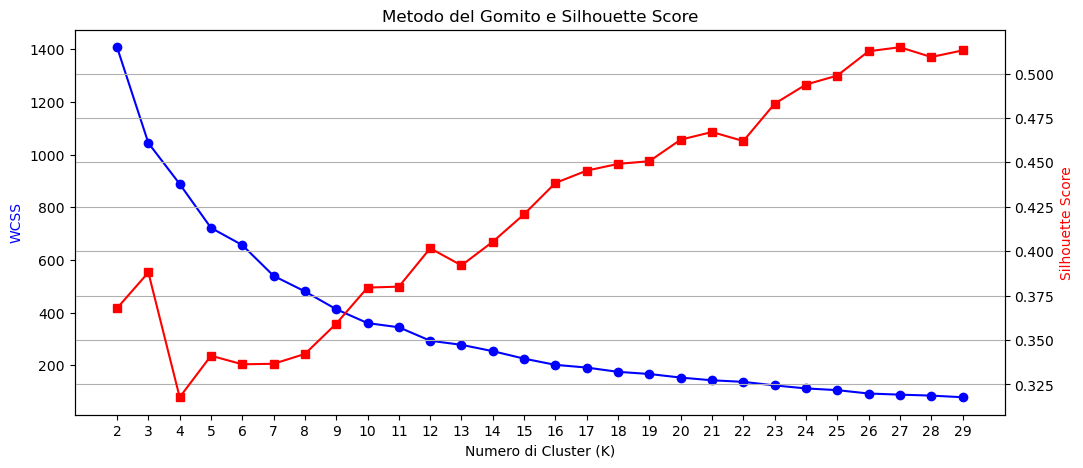

In [10]:
# Ricerca K ottimale (Elbow & Silhouette)
if 'embeddings_5d' in globals():
    wcss = []
    silhouette_avg_scores = []
    K_range = range(2, 30)

    for i in K_range:
        kmeans_temp = KMeans(n_clusters=i, random_state=42, n_init='auto')
        kmeans_temp.fit(embeddings_5d)
        wcss.append(kmeans_temp.inertia_)
        silhouette_avg_scores.append(silhouette_score(embeddings_5d, kmeans_temp.labels_))

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(K_range, wcss, 'b-', marker='o')
    ax1.set_xlabel('Numero di Cluster (K)')
    ax1.set_ylabel('WCSS', color='b')
    ax1.set_xticks(K_range)

    ax2 = ax1.twinx()
    ax2.plot(K_range, silhouette_avg_scores, 'r-', marker='s')
    ax2.set_ylabel('Silhouette Score', color='r')
    ax2.set_xticks(K_range)

    plt.title('Metodo del Gomito e Silhouette Score')
    plt.grid(True)
    if globals().get('salva_grafici', True):
        plt.savefig('elbow_silhouette.png', bbox_inches='tight')
    plt.show()



In [11]:
# Applichiamo il K-Means con un numero di cluster scelto (es. 10)
if 'embeddings_5d' in globals():
    n_clusters = 10
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    df_documents_with_tfidf['km_label'] = kmeans.fit_predict(embeddings_5d)

    print(f"Clustering K-Means completato con {n_clusters} cluster.")
    display(df_documents_with_tfidf['km_label'].value_counts().sort_index().to_frame())



Clustering K-Means completato con 10 cluster.


c:\Users\skywa\anaconda3\envs\env_master_2026\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,count
km_label,
0,34
1,110
2,80
3,10
4,18
5,57
6,37
7,72
8,40


### 7. Visualizzazione UMAP e Analisi Documenti


In [12]:
import umap
import umap.umap_ as umap
import plotly.express as px
if 'embeddings_5d' in globals():
    # Calcolo UMAP
    reducer = umap.UMAP( n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42)
    
    components_umap = reducer.fit_transform(embeddings_5d)
    # Creazione DataFrame arricchito con i metadati per il tooltip interattivo
    df_umap = pd.DataFrame(data=components_umap, columns=['Dim1', 'Dim2'])
    
    # Plotly preferisce etichette testuali per trattare i colori in modo discreto (categoriale)
    df_umap['km_label'] = 'Cluster ' + df_documents_with_tfidf['km_label'].astype(str)
    
    # Aggiungiamo i metadati per l'hover (quando passi il mouse sopra i punti)
    df_umap['country'] = df_documents_with_tfidf['country']
    df_umap['period'] = df_documents_with_tfidf['period']
    #df_umap['filename'] = df_documents_with_tfidf['filename']
        #mappatura paesi in macro regioni
    paesi_continenti = {
        "Angola": "Africa",
        "Burundi": "Africa",
        "Central African Republic": "Africa",
        "Democratic Republic of the Congo": "Africa",
        "Djibouti": "Africa",
        "Eswatini": "Africa",
        "Ethiopia": "Africa",
        "Kenya": "Africa",
        "Lesotho": "Africa",
        "Madagascar": "Africa",
        "Malawi": "Africa",
        "Mozambique": "Africa",
        "Namibia": "Africa",
        "Somalia": "Africa",
        "South Africa": "Africa",
        "South Sudan": "Africa",
        "Sudan": "Africa",
        "Uganda": "Africa",
        "United Republic of Tanzania": "Africa",
        "Zambia": "Africa",
        "Zimbabwe": "Africa",
        "Afghanistan": "Asia",
        "Bangladesh": "Asia",
        "Cambodia": "Asia",
        "Gaza Strip": "Asia",
        "Lebanon": "Asia",
        "Pakistan": "Asia",
        "Tajikistan": "Asia",
        "Timor-Leste": "Asia",
        "Yemen": "Asia",
        "Dominican Republic": "America",
        "Ecuador": "America",
        "El Salvador": "America",
        "Guatemala": "America",
        "Haiti": "America",
        "Honduras": "America"
    }
    
    df_umap['continente'] = df_umap['country'].map(paesi_continenti).fillna('Altro')
    # Generazione grafico interattivo con Plotly
    fig = px.scatter(
        df_umap, 
        x='Dim1', 
        y='Dim2', 
        color='km_label',
        symbol='continente',
        hover_data=['country', 'period', 'continente'],
        title='Distribuzione dei Cluster (UMAP 2D) - Mappa Interattiva',
        color_discrete_sequence=px.colors.qualitative.Alphabet,
        height=700
    )
    
    fig.update_traces(marker=dict(size=9, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
    
    
    
    import plotly.graph_objects as go
    added_colors = set()
    added_symbols = set()
    
    # Primo passaggio: aggiungiamo SOLO le voci per i Cluster
    for trace in list(fig.data):
        trace.showlegend = False
        parts = str(trace.name).split(', ')
        c_name = parts[0] if len(parts) > 0 else 'Sconosciuto'
        
        # Assegniamo la traccia reale al gruppo del cluster per poterla spegnere cliccando la legenda
        trace.legendgroup = c_name
        
        if c_name not in added_colors:
            fig.add_trace(go.Scatter(
                x=[None], y=[None], mode='markers',
                marker=dict(size=10, color=trace.marker.color, symbol='circle'),
                name=c_name, legendgroup=c_name
            ))
            added_colors.add(c_name)
            
    # Secondo passaggio: aggiungiamo SOLO le voci per i Continenti (così appaiono sotto in blocco)
    for trace in list(fig.data):
        # Evitiamo di ritoccare showlegend e legendgroup, ci serve solo aggiungere i dummy symbol
        parts = str(trace.name).split(', ')
        s_name = parts[1] if len(parts) > 1 else 'Altro'
        
        if s_name not in added_symbols:
            fig.add_trace(go.Scatter(
                x=[None], y=[None], mode='markers',
                marker=dict(size=10, color='gray', symbol=trace.marker.symbol),
                name=s_name, legendgroup=s_name
            ))
            added_symbols.add(s_name)
    if globals().get('salva_grafici', True):
        fig.write_html('umap_kmeans.html')
    fig.show()




c:\Users\skywa\anaconda3\envs\env_master_2026\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
# Ispezione Documenti nel Cluster 0
if 'km_label' in df_documents_with_tfidf.columns:
    cluster_0_docs = df_documents_with_tfidf[df_documents_with_tfidf['km_label'] == 0]
    print(f"Numero di documenti nel Cluster 0: {len(cluster_0_docs)}")

    if len(cluster_0_docs) >= 2:
        sample_docs = cluster_0_docs.sample(n=2, random_state=42)
        for index, row in sample_docs.iterrows():
            print(f"\n--- {row['filename']} ---")
            print(f"Top Unigrammi: {', '.join([w for w, c in row['top_unigrams_per_doc']])}")


Numero di documenti nel Cluster 0: 34

--- Zambia_Jul_2020_-_Mar_2021_KeyResults.txt ---
Top Unigrammi: food, acute, people, insecurity, population, high, household, flooding, normal, rainfall

--- Malawi_Jul_2019_-_Mar_2020_KeyResults.txt ---
Top Unigrammi: people, urgent, flood, food, year, severe, humanitarian, assistance, livelihood, support


### 7.b Clustering dei Documenti (HDBSCAN)


In [14]:
import hdbscan

if 'embeddings_5d' in globals():
    # Impostiamo min_cluster_size=5 come default iniziale
    hdb = hdbscan.HDBSCAN(min_cluster_size=15, min_samples = 5, metric="manhattan")
    df_documents_with_tfidf['hd_label'] = hdb.fit_predict(embeddings_5d)
    
    print(f"Clustering HDBSCAN completato.")
    display(df_documents_with_tfidf['hd_label'].value_counts().sort_index().to_frame())



Clustering HDBSCAN completato.


,count
hd_label,
-1,116
0,18
1,31
2,30
3,18
4,15
5,26
6,133
7,23


### 7.c Visualizzazione UMAP per HDBSCAN


In [15]:
if 'embeddings_5d' in globals() and 'hd_label' in df_documents_with_tfidf.columns:
    if 'components_umap' not in globals():
        reducer = umap.UMAP(n_components=2, random_state=42)
        components_umap = reducer.fit_transform(embeddings_5d)
    
    df_umap_hdb = pd.DataFrame(data=components_umap, columns=['Dim1', 'Dim2'])
    df_umap_hdb['km_label'] = 'Cluster ' + df_documents_with_tfidf['hd_label'].astype(str)
    df_umap_hdb['country'] = df_documents_with_tfidf['country']
    df_umap_hdb['period'] = df_documents_with_tfidf['period']
    
    # Usa paesi_continenti se definito in precedenza
    if 'paesi_continenti' in globals():
        df_umap_hdb['continente'] = df_umap_hdb['country'].map(paesi_continenti).fillna('Altro')
    else:
        df_umap_hdb['continente'] = 'Altro'
    
    fig = px.scatter(
        df_umap_hdb, 
        x='Dim1', 
        y='Dim2', 
        color='km_label',
        symbol='continente',
        hover_data=['country', 'period', 'continente'],
        title='Distribuzione dei Cluster HDBSCAN (UMAP 2D)',
        color_discrete_sequence=px.colors.qualitative.Alphabet,
        height=700
    )
    
    fig.update_traces(marker=dict(size=9, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
    
    
    
    import plotly.graph_objects as go
    added_colors = set()
    added_symbols = set()
    
    # Primo passaggio: aggiungiamo SOLO le voci per i Cluster
    for trace in list(fig.data):
        trace.showlegend = False
        parts = str(trace.name).split(', ')
        c_name = parts[0] if len(parts) > 0 else 'Sconosciuto'
        
        # Assegniamo la traccia reale al gruppo del cluster per poterla spegnere cliccando la legenda
        trace.legendgroup = c_name
        
        if c_name not in added_colors:
            fig.add_trace(go.Scatter(
                x=[None], y=[None], mode='markers',
                marker=dict(size=10, color=trace.marker.color, symbol='circle'),
                name=c_name, legendgroup=c_name
            ))
            added_colors.add(c_name)
            
    # Secondo passaggio: aggiungiamo SOLO le voci per i Continenti (così appaiono sotto in blocco)
    for trace in list(fig.data):
        # Evitiamo di ritoccare showlegend e legendgroup, ci serve solo aggiungere i dummy symbol
        parts = str(trace.name).split(', ')
        s_name = parts[1] if len(parts) > 1 else 'Altro'
        
        if s_name not in added_symbols:
            fig.add_trace(go.Scatter(
                x=[None], y=[None], mode='markers',
                marker=dict(size=10, color='gray', symbol=trace.marker.symbol),
                name=s_name, legendgroup=s_name
            ))
            added_symbols.add(s_name)
    if globals().get('salva_grafici', True):
        fig.write_html('umap_hdbscan.html')
    fig.show()




### 7.d Analisi delle tematiche tramite c-TF-IDF (BERTopic)
In questa sezione estraiamo i topic modeling per i cluster usando l'approccio c-TF-IDF (Class-based TF-IDF), sia per K-Means che per HDBSCAN.

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer

def estrai_parole_chiave_bertopic(df: pd.DataFrame, cluster_col: str, text_col: str = 'preprocessed_text', top_n: int = 10) -> dict:
    """
    Estrae le parole chiave applicando l'aggregazione spaziale a livello di cluster
    e calcolando il c-TF-IDF tramite BERTopic.
    """
    # 1. Aggregazione spaziale: concateniamo tutti i report pre-processati appartenenti allo stesso cluster
    class_docs = df.groupby(cluster_col)[text_col].apply(lambda testi: ' '.join(testi.fillna(''))).reset_index()

    # 2. Creazione matrice dei conteggi sui testi
    #vectorizer = CountVectorizer(max_features=1000)
    vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=3000)
    X = vectorizer.fit_transform(class_docs[text_col])

    # 3. Trasformazione c-TF-IDF
    ctfidf_transformer = ClassTfidfTransformer()
    ctfidf_matrix = ctfidf_transformer.fit_transform(X)

    # 4. Estrazione delle keyword
    terms = vectorizer.get_feature_names_out()
    keywords_per_cluster = {}

    for index, row in class_docs.iterrows():
        cluster_id = row[cluster_col]
        class_scores = ctfidf_matrix[index].toarray().flatten()

        # Ordinamento inverso per i punteggi più alti
        top_indices = class_scores.argsort()[::-1][:top_n]
        keywords_per_cluster[cluster_id] = [terms[i] for i in top_indices]

    return keywords_per_cluster


In [17]:
if 'km_label' in df_documents_with_tfidf.columns:
    print("\n--- Tematiche c-TF-IDF per K-Means ---")
    keywords_kmeans = estrai_parole_chiave_bertopic(df_documents_with_tfidf, 'km_label')
    for cluster_id, kws in keywords_kmeans.items():
        print(f"Cluster {cluster_id}: {', '.join(kws)}")

if 'hd_label' in df_documents_with_tfidf.columns:
    print("\n--- Tematiche c-TF-IDF per HDBSCAN ---")
    keywords_hdbscan = estrai_parole_chiave_bertopic(df_documents_with_tfidf, 'hd_label')
    for cluster_id, kws in keywords_hdbscan.items():
        if cluster_id != -1:  # Saltiamo il noise
            print(f"Cluster {cluster_id}: {', '.join(kws)}")



--- Tematiche c-TF-IDF per K-Means ---
Cluster 0: people, food, high, acute, food insecurity, insecurity, population, acute food, price, spell
Cluster 1: food, household, poor, price, situation, population, production, crop, access, high
Cluster 2: people, population, food, high, people population, food insecurity, insecurity, acute food, high acute, acute
Cluster 3: analyzed, analyzed population, people analyzed, people, population, population people, insecurity people, food insecurity, insecurity, food
Cluster 4: malnutrition, acute, acute malnutrition, child, situation, food, high, food insecurity, insecurity, acute food
Cluster 5: food, population, insecurity, humanitarian, food insecurity, assistance, people, situation, emergency, security
Cluster 6: basic, grain, coffee, food, income, household, basic grain, department, loss, access
Cluster 7: people, food, population, insecurity, acute, food insecurity, acute food, people population, bad, high
Cluster 8: refugee, population, pe

### 7.e Valutazione e Confronto Modelli
Confrontiamo K-Means e HDBSCAN calcolando le principali metriche di validazione dei cluster.

In [18]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

if 'embeddings_5d' in globals() and 'km_label' in df_documents_with_tfidf.columns and 'hd_label' in df_documents_with_tfidf.columns:
    # --- FILTRO PER HDBSCAN (Escludiamo gli outlier -1 dalle metriche di distanza) ---
    mask_hdb = df_documents_with_tfidf["hd_label"] != -1
    df_filtered = df_documents_with_tfidf[mask_hdb]
    features_filtered = embeddings_5d[mask_hdb]
    
    # --- CALCOLO METRICHE K-MEANS ---
    km_sil = silhouette_score(embeddings_5d, df_documents_with_tfidf["km_label"])
    km_ch = calinski_harabasz_score(embeddings_5d, df_documents_with_tfidf["km_label"])
    km_db = davies_bouldin_score(embeddings_5d, df_documents_with_tfidf["km_label"])
    
    # --- CALCOLO METRICHE HDBSCAN ---
    if len(df_filtered["hd_label"].unique()) > 1:
        hdb_sil = silhouette_score(features_filtered, df_filtered["hd_label"])
        hdb_ch = calinski_harabasz_score(features_filtered, df_filtered["hd_label"])
        hdb_db = davies_bouldin_score(features_filtered, df_filtered["hd_label"])
    else:
        import math
        hdb_sil, hdb_ch, hdb_db = math.nan, math.nan, math.nan
    
    # --- COSTRUZIONE TABELLA DI CONFRONTO ---
    confronto_data = {
        "Metrica": [
            "Numero di Cluster trovati",
            "Percentuale Rumore / Outliers",
            "Silhouette Score (Più alto = meglio)",
            "Calinski-Harabasz Index (Più alto = meglio)",
            "Davies-Bouldin Index (Più basso = meglio)"
        ],
        "K-Means": [
            df_documents_with_tfidf["km_label"].nunique(),
            "0.0% (Forza tutti i punti)",
            f"{km_sil:.3f}",
            f"{km_ch:.1f}",
            f"{km_db:.3f}"
        ],
        "HDBSCAN": [
            df_filtered["hd_label"].nunique(),
            f"{(~mask_hdb).sum() / len(df_documents_with_tfidf) * 100:.1f}%",
            f"{hdb_sil:.3f}" if not pd.isna(hdb_sil) else "N/A",
            f"{hdb_ch:.1f}" if not pd.isna(hdb_ch) else "N/A",
            f"{hdb_db:.3f}" if not pd.isna(hdb_db) else "N/A"
        ]
    }
    
    df_confronto = pd.DataFrame(confronto_data)
    print("\n=== TABELLA COMPARATIVA DEL CLUSTERING ===")
    display(df_confronto)




=== TABELLA COMPARATIVA DEL CLUSTERING ===


,Metrica,K-Means,HDBSCAN
0,Numero di Cluster trovati,10,11
1,Percentuale Rumore / Outliers,0.0% (Forza tutti i punti),23.3%
2,Silhouette Score (Più alto = meglio),0.380,0.386
3,Calinski-Harabasz Index (Più alto = meglio),280.6,219.0
4,Davies-Bouldin Index (Più basso = meglio),0.889,0.884


### 7.f Confronto Diretto tra K-Means e HDBSCAN (ARI e NMI)
Calcoliamo due metriche fondamentali per valutare la concordanza tra i partizionamenti generati dai due algoritmi:
1. **Adjusted Rand Index (ARI)**: misura la similarità tra i due assegnamenti ignorando le permutazioni. Varia da -1 a 1 (1 = cluster identici).
2. **Normalized Mutual Information (NMI)**: misura l'informazione reciproca normalizzata, utile per quantificare quanta informazione del primo clustering si ritrova nel secondo. Varia da 0 a 1.

In [19]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

if 'km_label' in df_documents_with_tfidf.columns and 'hd_label' in df_documents_with_tfidf.columns:
    # Teniamo tutti i dati, compresi i -1 di hdbscan (che verranno visti come un cluster a sé)
    ari_score = adjusted_rand_score(df_documents_with_tfidf['km_label'], df_documents_with_tfidf['hd_label'])
    nmi_score = normalized_mutual_info_score(df_documents_with_tfidf['km_label'], df_documents_with_tfidf['hd_label'])

    print("============================================================")
    print("CONFRONTO K-MEANS vs HDBSCAN")
    print("============================================================")
    print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
    print(f"Normalized Mutual Info (NMI): {nmi_score:.4f}")
    print("\n* Valori vicini a 1 indicano una forte sovrapposizione tra i due algoritmi.")
    print("* Valori vicini a 0 indicano partizionamenti indipendenti/differenti.")


CONFRONTO K-MEANS vs HDBSCAN
Adjusted Rand Index (ARI): 0.3356
Normalized Mutual Info (NMI): 0.6220

* Valori vicini a 1 indicano una forte sovrapposizione tra i due algoritmi.
* Valori vicini a 0 indicano partizionamenti indipendenti/differenti.


### 8. Mappa Geografica dei Cluster
Questa mappa interattiva mostra il Cluster prevalente (più frequente) per ogni paese. Passando il mouse sul paese, è possibile vedere anche tutti gli altri cluster in cui il paese è finito in altri periodi storici.

In [ ]:
import plotly.express as px

if 'df_documents_with_tfidf' in globals():
    # Raggruppa i documenti per paese
    df_map = df_documents_with_tfidf.groupby('country').agg(
        Cluster_Prevalente=('km_label', lambda x: 'Cluster ' + str(x.mode()[0])),
        Tutti_i_Cluster=('km_label', lambda x: ', '.join(sorted(list(set('Cluster ' + str(c) for c in x)))))
    ).reset_index()

    # Genera la mappa Choropleth
    fig = px.choropleth(
        df_map,
        locations="country",
        locationmode="country names",
        color="Cluster_Prevalente",
        hover_name="country",
        hover_data={"Cluster_Prevalente": False, "Tutti_i_Cluster": True, "country": False},
        title="Mappa Globale: Cluster Prevalente per Paese",
        color_discrete_sequence=px.colors.qualitative.Alphabet,
        height=600
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'),
        margin=dict(l=0, r=0, t=50, b=0)
    )
    if globals().get('salva_grafici', True):
        fig.write_html('mappa_globale_kmeans.html')
    fig.show()


C:\Users\skywa\AppData\Local\Temp\ipykernel_23092\4240796931.py:11: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


: 

### 9. Mappa Interattiva: Filtro per Cluster
Questa cella permette di selezionare un singolo Cluster tramite un menu a tendina. La mappa evidenzierà tutti i paesi che hanno almeno un documento in quel cluster. Passando il mouse sul paese, potrai vedere in quali **periodi** il paese è rientrato in questo cluster.

In [ ]:
import plotly.graph_objects as go

if 'df_documents_with_tfidf' in globals():
    clusters = sorted(df_documents_with_tfidf['km_label'].unique())
    fig = go.Figure()

    # Creiamo un "livello" (trace) per ogni cluster
    for c in clusters:
        df_cluster = df_documents_with_tfidf[df_documents_with_tfidf['km_label'] == c]
        
        # Raggruppiamo per paese
        df_map_cluster = df_cluster.groupby('country').agg(
            periodi=('period', lambda x: '<br>'.join(sorted(x)))
        ).reset_index()
        
        # Aggiungiamo la mappa per questo cluster
        fig.add_trace(go.Choropleth(
            locations=df_map_cluster['country'],
            locationmode='country names',
            z=[1] * len(df_map_cluster), # Valore fittizio per il colore uniforme
            colorscale=[[0, '#ef553b'], [1, '#ef553b']], # Colore rosso/arancio fisso
            showscale=False, # Nascondiamo la barra dei colori
            text=df_map_cluster['periodi'],
            hovertemplate='<b>%{location}</b><br><br><b>Periodi:</b><br>%{text}<extra></extra>',
            name=f"Cluster {c}",
            visible=(c == clusters[0]) # Mostriamo solo il primo all'avvio
        ))

    # Creiamo i pulsanti per il menu a tendina NATIVO di Plotly
    buttons = []
    for i, c in enumerate(clusters):
        visibility = [False] * len(clusters)
        visibility[i] = True
        
        button = dict(
            label=f"Cluster {c}",
            method="update",
            args=[{"visible": visibility},
                  {"title": f"Paesi appartenenti al Cluster {c}"}]
        )
        buttons.append(button)

    # Aggiungiamo il menu al layout
    fig.update_layout(
        updatemenus=[
            dict(
                active=0,
                buttons=buttons,
                x=0.0,
                xanchor="left",
                y=1.15,
                yanchor="top",
                direction="down",
                showactive=True,
            )
        ],
        title=f"Paesi appartenenti al Cluster {clusters[0]}",
        geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'),
        margin=dict(l=0, r=0, t=80, b=0),
        height=600
    )

    if globals().get('salva_grafici', True):
        fig.write_html('mappa_filtro_cluster.html')
    fig.show()


: 

### 9. Analisi Cronologica dei Cluster (Altair)
Mappa interattiva con tooltip e heatmap cronologica per singolo paese al click.

In [20]:
import altair as alt
import pandas as pd
import os

if 'df_umap' in globals():
    # 1. PARSING E ORDINAMENTO CRONOLOGICO
    # Lasciamo fare a pandas l'inferenza del formato rimuovendo format='%b %Y' per essere robusti con tutte le lingue
    df_umap['data_inizio'] = pd.to_datetime(df_umap['period'].str.split(' / ').str[0], errors='coerce')
    df_umap = df_umap.sort_values(by=["country", "data_inizio"])
    
    if "continente" not in df_umap.columns:
        print("Errore critico: Colonna 'continente' mancante nel DataFrame.")
    
    # 2. DEFINIZIONE DEI PARAMETRI DI SELEZIONE
    click_dissolvenza = alt.selection_point(
        fields=['country'],
        on='click',
        empty=True,
        clear='dblclick'
    )
    
    click_filtro = alt.selection_point(
        fields=['country'],
        on='click',
        empty=False,
        clear='dblclick'
    )
    
    # 3. CREAZIONE DELLO SCATTER PLOT (Grafico Superiore)
    punti = alt.Chart(df_umap).mark_point(
        filled=True,
        size=100,
        stroke='black',
        strokeWidth=0.5
    ).encode(
        x=alt.X('Dim1:Q', title='Componente UMAP 1', scale=alt.Scale(zero=False)),
        y=alt.Y('Dim2:Q', title='Componente UMAP 2', scale=alt.Scale(zero=False)),
        color=alt.Color('km_label:N', legend=alt.Legend(title="Driver Semantico")),
        shape=alt.Shape('continente:N', legend=alt.Legend(title="Continente")),
        opacity=alt.condition(click_dissolvenza, alt.value(0.9), alt.value(0.05)),
        tooltip=['country:N', 'period:N', 'continente:N', 'km_label:N']
    ).add_params(
        click_dissolvenza,
        click_filtro
    ).properties(
        width=950,
        height=550,
        title="Clustering Semantico dei Report (Clicca su un marker per isolare un paese)"
    )
    
    # 4. CREAZIONE DELLA HEATMAP MONOLINEA (Grafico Inferiore)
    heatmap_temporale = alt.Chart(df_umap).mark_rect(
        stroke='white', # Aggiunge un bordo bianco tra le celle per separarle visivamente
        strokeWidth=1
    ).encode(
        x=alt.X(
            'period:O',
            title='Periodo',
            # Usiamo op='min' per assicurarci che ordini in base al tempo effettivo
            sort=alt.EncodingSortField(field='data_inizio', op='min', order='ascending'),
            axis=alt.Axis(labelAngle=-45, labelOverlap=False)
        ),
        y=alt.Y(
            'country:N',
            title='Paese Selezionato',
            # Orient=left per non far spostare la legenda, e labelLimit per non tagliare il nome
            axis=alt.Axis(orient='left', labelLimit=500) 
        ),
        color=alt.Color(
            'km_label:N',
            legend=None # Legenda soppressa, eredita quella dello scatter plot
        ),
        tooltip=['country:N', 'period:N', 'km_label:N']
    ).transform_filter(
        click_filtro
    ).properties(
        width=950,
        height=60, # Altezza compressa per ospitare una singola riga
        title="Cronologia Cluster (Heatmap per il paese selezionato)"
    )
    
    # 5. ASSEMBLAGGIO FINALE
    grafico_finale = alt.vconcat(
        punti,
        heatmap_temporale
    ).configure_view(
        strokeWidth=0
    ).configure(
        padding={"bottom": 80} # Padding mantenuto per non tagliare l'asse X ruotato
    )
    
    # 6. SALVATAGGIO E RENDERING
    output_html_path_altair = "mappa_percorsi_altair_click_heatmap.html"
    if 'DRIVE_PATH' in locals() or 'DRIVE_PATH' in globals():
        output_html_path_altair = os.path.join(DRIVE_PATH, output_html_path_altair)
    
    if globals().get('salva_grafici', True):
        grafico_finale.save(output_html_path_altair)
        print(f"Grafico Altair salvato in: {output_html_path_altair}")
    
    display(grafico_finale)



Grafico Altair salvato in: mappa_percorsi_altair_click_heatmap.html


alt.VConcatChart(...)

In [ ]:
#df_documents_with_tfidf[['country','period','km_label','hd_label']].to_parquet('df_cluster.parquet',index=False)

,filename,country,period,text,top_unigrams_per_doc,unigram_counts,preprocessed_text,top_bigrams_per_doc,SVD_0,SVD_1,...,SVD_42,SVD_43,SVD_44,SVD_45,SVD_46,SVD_47,SVD_48,SVD_49,km_label,hd_label
0,Democratic_Republic_of_the_Congo_Dec_2012_-_De...,Democratic Republic of the Congo,Dec 2012 / Dec 2012,The 8th analysis cycle on the Integrated Food ...,"[(food, 8), (people, 7), (conflict, 6), (situa...","{'cycle': 3, 'people': 7, 'situation': 4, 'foo...",cycle people situation food livelihood crisis ...,"[(armed conflict, 4), (food livelihood, 2), (l...",0.235004,0.012667,...,0.002920,0.074681,-0.029017,0.005184,-0.064188,-0.003697,0.019043,0.001288,8,2
1,Burundi_Nov_2024_-_Mar_2025_KeyResults.txt,Burundi,Nov 2024 / Mar 2025,"Between January and March , which coincides wi...","[(people, 2), (improvement, 2), (high, 2), (ha...","{'harvest': 1, 'people': 2, 'population': 1, '...",harvest people population marked improvement p...,"[(harvest people, 1), (people population, 1), ...",0.209420,0.054661,...,0.058538,-0.055122,-0.087876,0.062094,0.041128,0.009395,-0.069258,-0.005202,2,6
2,Madagascar_Aug_2017_-_Mar_2018_KeyResults.txt,Madagascar,Aug 2017 / Mar 2018,The period from August to October coincides w...,"[(food, 5), (situation, 5), (population, 5), (...","{'harvest': 2, 'beginning': 1, 'lean': 2, 'hou...",harvest beginning lean household insufficient ...,"[(percentage population, 2), (population peopl...",0.309904,0.091925,...,-0.026431,0.061262,-0.010563,0.071203,0.105817,0.054000,0.063517,0.009137,1,9
3,Yemen_Oct_2023_-_Feb_2024_KeyResults.txt,Yemen,Oct 2023 / Feb 2024,The updated analysis indicates that for the pe...,"[(food, 6), (population, 3), (insecurity, 3), ...","{'people': 2, 'population': 3, 'high': 2, 'acu...",people population high acute food insecurity p...,"[(food insecurity, 3), (high acute, 2), (acute...",0.354542,-0.082566,...,0.056507,0.018453,0.040138,0.021381,-0.023784,-0.000152,0.004052,-0.023986,5,6
4,Mozambique_Apr_2018_-_Sep_2018_KeyResults.txt,Mozambique,Apr 2018 / Sep 2018,DISCLAIMER: please note that this IPC Acute Fo...,"[(food, 5), (late, 2), (acute, 2), (insecurity...","{'information': 1, 'late': 2, 'acute': 2, 'foo...",information late acute food insecurity situati...,"[(acute food, 2), (food insecurity, 2), (infor...",0.215365,0.092732,...,0.077892,-0.076877,-0.057475,-0.029862,0.011080,0.112761,-0.054193,-0.016874,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,Lesotho_Jul_2022_-_Mar_2023_KeyResults.txt,Lesotho,Jul 2022 / Mar 2023,According to the latest results of an IPC Acut...,"[(people, 2), (population, 2), (crop, 2), (yea...","{'late': 1, 'people': 2, 'population': 2, 'urg...",late people population urgent action food gap ...,"[(people population, 2), (late people, 1), (po...",0.235661,0.048709,...,0.068301,-0.105673,0.005986,-0.006392,0.004888,-0.023178,0.030712,0.024372,0,1
493,Zimbabwe_May_2016_-_Mar_2017_KeyResults.txt,Zimbabwe,May 2016 / Mar 2017,"In the period from April-June , the experienc...","[(food, 9), (crop, 4), (poor, 4), (household, ...","{'late': 3, 'start': 1, 'rain': 3, 'reduction'...",late start rain reduction crop early crop prol...,"[(poor household, 2), (food consumption, 2), (...",0.278101,0.304189,...,-0.084298,-0.003406,0.002454,-0.054522,0.066320,0.074161,0.027882,-0.074145,1,7
494,Djibouti_May_2013_-_May_2013_KeyResults.txt,Djibouti,May 2013 / May 2013,Food availability in the is mainly provided b...,"[(food, 16), (insecurity, 5), (access, 3), (pr...","{'food': 16, 'availability': 1, 'import': 2, '...",food availability import food requirement food...,"[(food insecurity, 5), (food access, 3), (incr...",0.231015,0.136185,...,-0.058736,-0.032180,0.087759,-0.008250,0.042714,-0.032923,-0.067098,0.073146,1,-1
495,Uganda_Jul_2024_-_Jun_2025_KeyResults.txt,Uganda,Jul 2024 / Jun 2025,"Approximately 797,000 people in in are facin...","[(food, 5), (people, 4), (acute, 3), (insecuri...","{'people': 4, 'high': 2, 'acute': 3, 'food'